<h2 align='center' style="color:teal"> AtliqO Credit Card Project - Phase 2 </h2>

<h2>Launch of AB testing: Targeting Untapped Market</h2>

<h4>Insights specific to customers with age group of 18 - 25</h4>

- Young adults and middle-aged customers with age group of 18–25 accounts for 24% of customer base in the data
- Average annual income of this age group is less than 50k
- They don't have much credit history which is getting reflected in their credit score and max credit limit
- Usage of credit cards as payment type is relatively low compared to other groups
- Avg transaction amount made with credit cards is also low compared to other groups
- Top 3 most used shopping products categories :  Fashion & Apparel, Electronics, Beauty & Personal care

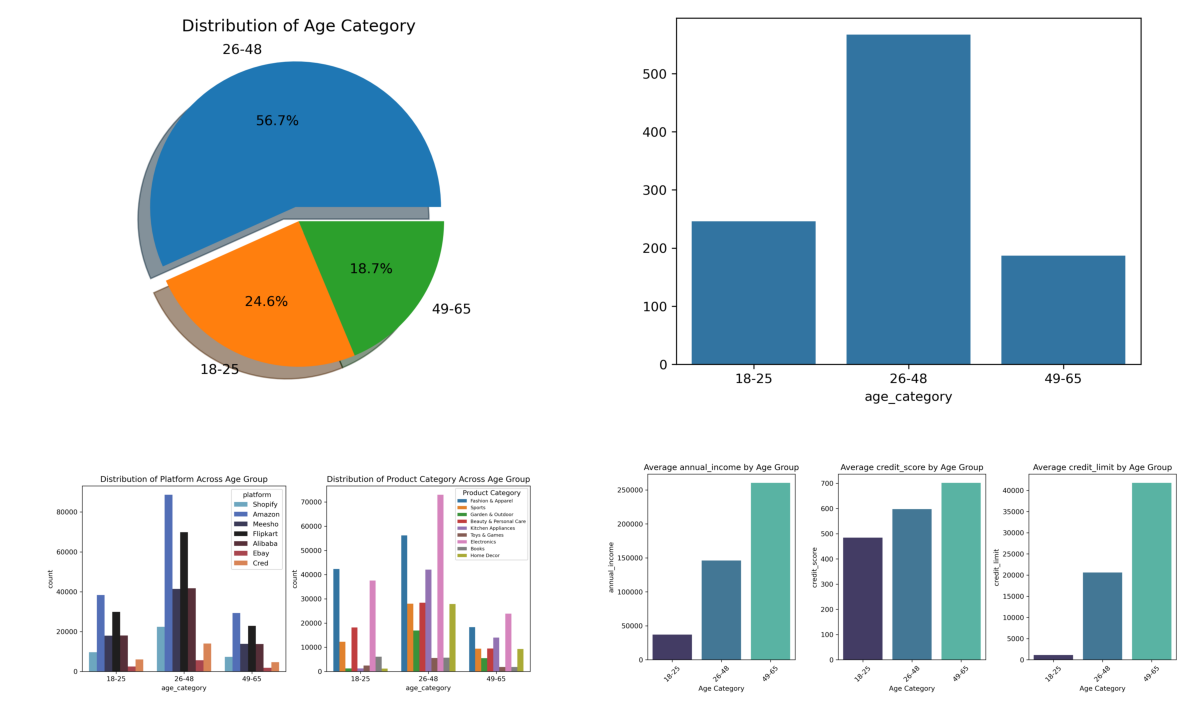

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

img1 = mpimg.imread("graph1.png") 
img2 = mpimg.imread("graph2.png")
img3 = mpimg.imread("graph3.png") 
img4 = mpimg.imread("graph5.png") 

gs = GridSpec(2, 2, width_ratios=[2,2])

fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])  
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1,1])

ax1.imshow(img1); ax1.axis("off")
ax2.imshow(img2); ax2.axis("off")
ax3.imshow(img3); ax3.axis("off")
ax4.imshow(img4); ax4.axis("off")

plt.tight_layout()
plt.show()

### (1) Pre-Campaign
We want to do a trial run for our new credit card. For this we need to figure out (1) How many customers do we need for our A/B testing. We will form a control and test group. For both of these groups we can figure out number of customers we need based on the statistical power and effect size that we agree upon after discussing with business. We will use

In [94]:
import statsmodels.stats.api as sms
import statsmodels.api as sm
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

In [98]:
# Calculate the required sample size for different effect sizes

alpha = 0.05 
power = 0.8
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5,1]

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, 
    ratio=1, alternative='two-sided')
    print(f"Effect Size: {effect_size} | Required Sample Size: {int(sample_size)} customers")

Effect Size: 0.1 | Required Sample Size: 1570 customers
Effect Size: 0.2 | Required Sample Size: 393 customers
Effect Size: 0.3 | Required Sample Size: 175 customers
Effect Size: 0.4 | Required Sample Size: 99 customers
Effect Size: 0.5 | Required Sample Size: 63 customers
Effect Size: 1 | Required Sample Size: 16 customers


Based on business requirements, the test should be capable of detecting a minimum 0.4 standard deviation difference between the control and test groups. For the effect size 0.4, we need 100 customers in terms of their budgeting constraints for this trail run.

#### Forming control and test groups

1.We have identified approximately 246 customers within the age group of 18 to 25. From this pool, we will select 100 customers for the initial campaign launch.

2.The campaign is launched for 100 customers, as determined by the effective size calculation and by considering budgeting costs, and will run campaign for a duration of 2 months

3.Got a conversion rate of ~40% ( implies 40 out of 100 customers in test group started using credit card)

4.To maintain a similar sample size, a control group consisting of 40 customers will be created. Importantly, this control group will be completely exclusive of initial 100 customers used as test group.

5.So now we have 40 customers in each of control and test groups

##### At the end of the 2-month campaign period (from 09-10-23 to 11-10-23), we obtained daily data showing the average transaction amounts made by the entire group of 40 customers in both the control and test groups using existing and newly launched credit cards respectively

##### The key performance indicator (KPI) for this AB test aims to enhance average transaction amounts facilitated by the new card

## (2) Post-Campaign


## Two Sample Z Test for Our Hypothesis Testing

In [80]:
# Loading avg transaction data after campaign

df = pd.read_csv("avg_transactions_after_campaign.csv")
df.head(5)

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
3,2023-09-13,214.92,214.85
4,2023-09-14,158.55,344.08


In [82]:
df.shape

(62, 3)

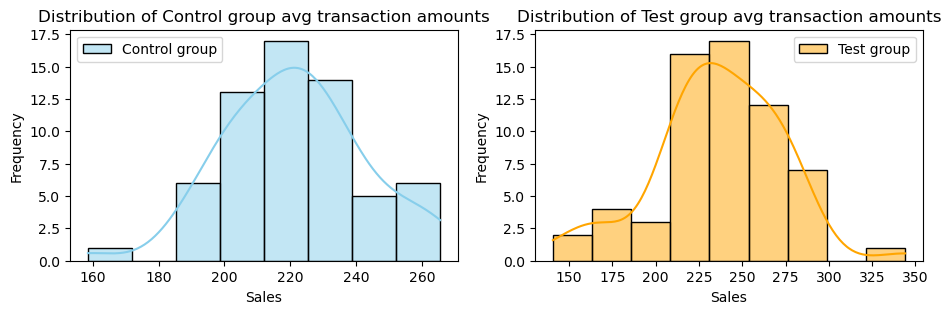

In [84]:
# Distributions of avg transactions amounts in both groups

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Campaign A Sales - Control group
sns.histplot(df['control_group_avg_tran'], kde=True, color='skyblue', label='Control group',ax=ax1)
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group avg transaction amounts')
ax1.legend()

# Campaign B Sales -  Test group 
sns.histplot(df['test_group_avg_tran'], kde=True, color='orange', label='Test group', ax=ax2)
ax2.set_xlabel('Sales')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Test group avg transaction amounts')
ax2.legend()

plt.show()

In [86]:
control_mean = round(df["control_group_avg_tran"].mean(),2)
control_std = round(df["control_group_avg_tran"].std(),2)
print(f" Control Group -> Mean:{control_mean}  Std:{control_std}")

test_mean = round(df["test_group_avg_tran"].mean(),2)
test_std = round(df["test_group_avg_tran"].std(),2)
print(f" Control Group -> Mean:{test_mean}  Std:{test_std}")


 Control Group -> Mean:221.18  Std:21.36
 Control Group -> Mean:235.98  Std:36.66


In [72]:
sample_size = df.shape[0]
sample_size

62

In [88]:
a = (control_std**2/sample_size)
b = (test_std**2/sample_size)

Z_score = (test_mean-control_mean)/np.sqrt(a+b)
print(Z_score)

2.7466072001806734


In [102]:
# For a significance level of 5% (0.05) in a right-tailed test, the critical Z-value is approximately 1.645

critical_z_value = st.norm.ppf(1 - alpha)  
print(critical_z_value)

1.6448536269514722


In [106]:
print(Z_score > critical_z_value)

True


#### Null Hypothesisi is Rejected. The average transaction of test group is better than the average transaction of control group.

In [133]:
# Calculating the 95% Confidence Interval for the test group

lower, upper = st.norm.interval(0.95, loc=test_mean, scale=test_std/np.sqrt(sample_size))
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

95% Confidence Interval: (218.41, 253.55)


#### With 95% confidence, the true mean transaction value lies between 218.41 and 253.55